# Lecture 3 — Regularization and Model Stability
**ECON 417 · Business Forecasting · Southern Illinois University Edwardsville**

In Lecture 2 we learned that out-of-sample RMSE is the only honest scorecard for a forecasting model.  
Today we ask: *why do models sometimes fail out-of-sample even when in-sample fit looks fine?*

One underappreciated culprit is **coefficient instability** — not the complexity of the model, but the *volatility* of its parameters across different samples of data.

Today's roadmap:

| Section | Topic |
|---------|-------|
| A | Why stability matters — the same model, different windows |
| B | Multicollinearity and coefficient volatility |
| C | Ridge regression — stability-oriented shrinkage |
| D | Lasso regression — shrinkage plus sparsity |
| E | Ridge vs. Lasso — choosing the right tool |
| F | Coding walkthrough — OLS, Ridge, Lasso side-by-side |


## Setup

In [1]:
%pip install yfinance scikit-learn statsmodels matplotlib --quiet


Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ── Consistent color palette (matches Lecture 1 & 2) ─────────────────────
COLORS = {
    'train':   '#2196F3',   # blue
    'val':     '#FF9800',   # orange
    'test':    '#4CAF50',   # green
    'ols':     '#E53935',   # red
    'ridge':   '#7B1FA2',   # purple
    'lasso':   '#00897B',   # teal
    'neutral': '#546E7A',   # slate
    'accent':  '#F4A261',   # warm orange
}

# ── Try real data; fall back to calibrated synthetic ─────────────────────
DATA_SOURCE = 'synthetic (calibrated to real S&P 500 properties)'
raw = None
try:
    import yfinance as yf
    tickers = ['^GSPC', '^VIX', 'MSFT', 'AAPL', 'JPM', 'XOM']
    _raw = yf.download(tickers, start='2015-01-01', end='2024-12-31',
                       auto_adjust=True, progress=False)
    if len(_raw) > 100:
        raw = _raw
        DATA_SOURCE = 'real (yfinance)'
except Exception:
    pass

if raw is not None:
    close = raw['Close'].dropna()
    sp500  = close['^GSPC']
    vix    = raw['Close']['^VIX'].reindex(sp500.index).ffill()
    msft   = close['MSFT']
    aapl   = close['AAPL']
    jpm    = close['JPM']
    xom    = close['XOM']
else:
    np.random.seed(42)
    dates = pd.date_range('2015-01-02', '2024-12-31', freq='B')
    N = len(dates)
    # Synthetic SP500 with realistic drift + vol
    sp500_ret = np.random.normal(0.0003, 0.010, N)
    sp500 = pd.Series(4000 * np.exp(np.cumsum(sp500_ret)), index=dates, name='^GSPC')
    # VIX: mean-reverting around 18, negatively correlated with SP500
    vix_vals = 18 + np.cumsum(np.random.normal(0, 0.2, N) - 0.3 * sp500_ret * 10)
    vix_vals = np.clip(vix_vals, 10, 80)
    vix = pd.Series(vix_vals, index=dates, name='^VIX')
    # Tech / bank / energy stocks - correlated with SP500
    def make_stock(base, beta, idio_vol):
        ret = beta * sp500_ret + np.random.normal(0, idio_vol, N)
        return pd.Series(base * np.exp(np.cumsum(ret)), index=dates)
    msft = make_stock(300, 1.2, 0.012)
    aapl = make_stock(150, 1.15, 0.013)
    jpm  = make_stock( 80, 1.05, 0.011)
    xom  = make_stock( 60, 0.80, 0.014)

# ── Build a log-return dataframe ─────────────────────────────────────────
df = pd.DataFrame({
    'SP500': sp500,
    'VIX':   vix,
    'MSFT':  msft,
    'AAPL':  aapl,
    'JPM':   jpm,
    'XOM':   xom,
}).dropna()

rets = np.log(df[['SP500','MSFT','AAPL','JPM','XOM']]).diff().dropna()
rets['VIX']      = df['VIX'].reindex(rets.index)
rets['VIX_chg']  = df['VIX'].diff().reindex(rets.index)
rets = rets.dropna()

print(f"Data source : {DATA_SOURCE}")
print(f"Date range  : {rets.index[0].date()} → {rets.index[-1].date()}")
print(f"Observations: {len(rets):,}")
rets.head()


Data source : real (yfinance)
Date range  : 2015-01-05 → 2024-12-30
Observations: 2,514


,SP500,MSFT,AAPL,JPM,XOM,VIX,VIX_chg
Date,,,,,,,
2015-01-05,-0.018447,-0.009239,-0.028576,-0.031537,-0.027743,19.920000,2.129999
2015-01-06,-0.008933,-0.014786,0.000094,-0.026271,-0.005330,21.120001,1.200001
2015-01-07,0.011563,0.012625,0.013924,0.001525,0.010081,19.309999,-1.810001
2015-01-08,0.017730,0.028994,0.037703,0.022100,0.016507,17.010000,-2.299999
2015-01-09,-0.008439,-0.008441,0.001072,-0.017540,-0.001411,17.549999,0.539999


---
## Section A — Why Stability Matters in Forecasting

### The problem: different windows, different stories

Imagine you fit a regression model to predict next-day S&P 500 returns using MSFT, AAPL, and VIX.  
You present the model to your manager in January. Three months later you re-estimate it on the most recent window.  

**Same target. Same predictors. Very different coefficients.**

This is not a bug — it is a warning signal.  
In forecasting, a model whose parameters swing dramatically across time windows is a model you **cannot trust** out-of-sample.

### Prediction accuracy vs. model reliability

| Concept | What it measures | When it fails |
|---------|-----------------|---------------|
| In-sample R² | How well the model *describes* history | Overfitting — memorising noise |
| Out-of-sample RMSE | How well the model *predicts* new data | Structural breaks, noise |
| **Coefficient stability** | Whether model *structure* is consistent | **Multicollinearity, small samples** |

The third row is what Lecture 3 is about.


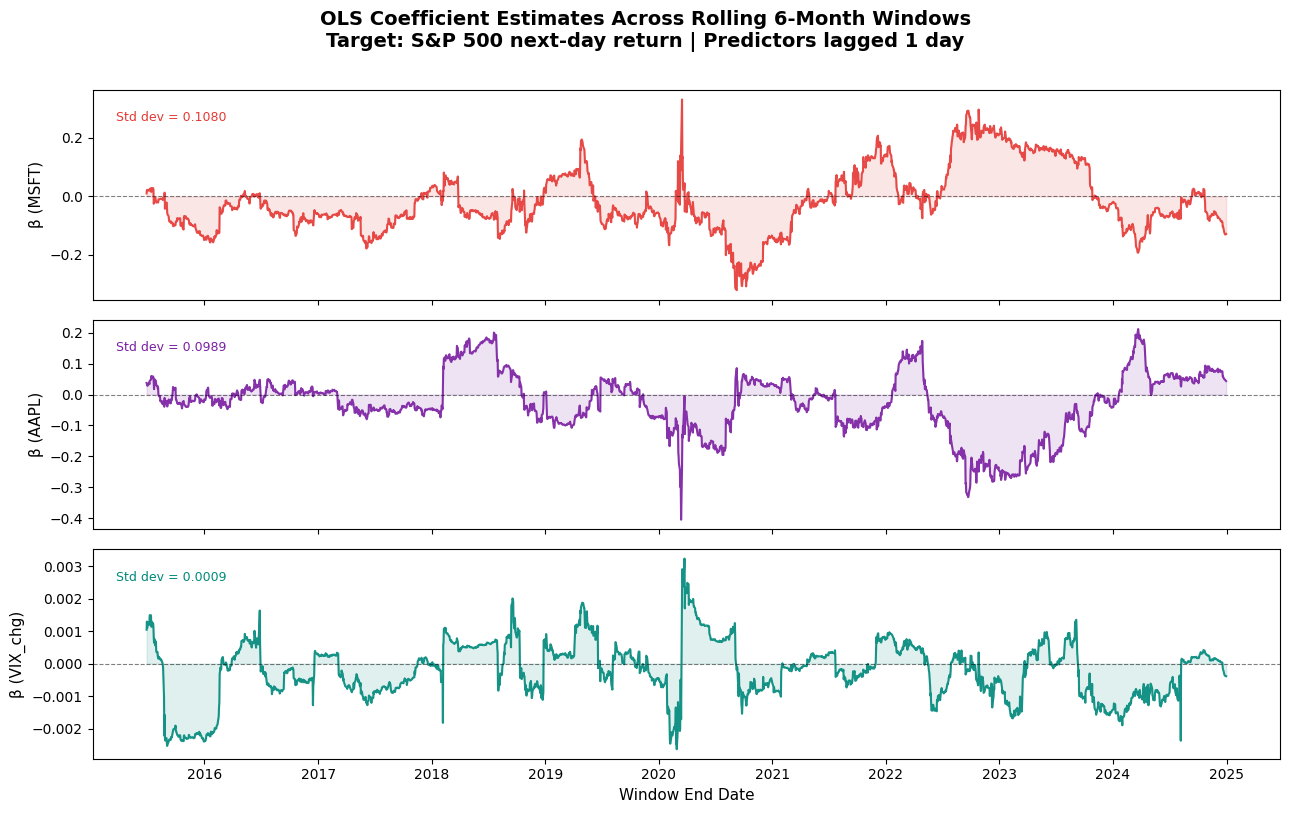

Figure A1 saved.


In [2]:
# ── Show coefficient instability across rolling windows ─────────────────
# Target: SP500 log return
# Predictors: MSFT_ret, AAPL_ret, VIX_chg  (all lagged one day)

target = 'SP500'
features = ['MSFT', 'AAPL', 'VIX_chg']

# Lag predictors by 1 day (information set constraint)
X_all = rets[features].shift(1).dropna()
y_all = rets[target].reindex(X_all.index)

WINDOW = 120   # ~6 months of trading days
coefs_over_time = {f: [] for f in features}
window_ends = []

for end in range(WINDOW, len(X_all)):
    X_w = X_all.iloc[end - WINDOW : end]
    y_w = y_all.iloc[end - WINDOW : end]
    m   = LinearRegression().fit(X_w, y_w)
    for i, f in enumerate(features):
        coefs_over_time[f].append(m.coef_[i])
    window_ends.append(X_all.index[end])

coef_df = pd.DataFrame(coefs_over_time, index=window_ends)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
fig.suptitle("OLS Coefficient Estimates Across Rolling 6-Month Windows\n"
             "Target: S&P 500 next-day return | Predictors lagged 1 day",
             fontsize=14, fontweight='bold', y=1.01)

for ax, feat, color in zip(axes, features, [COLORS['ols'], COLORS['ridge'], COLORS['lasso']]):
    ax.plot(coef_df.index, coef_df[feat], color=color, lw=1.5, alpha=0.9)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.fill_between(coef_df.index, coef_df[feat], 0, alpha=0.12, color=color)
    ax.set_ylabel(f'β ({feat})', fontsize=11)
    std_ = coef_df[feat].std()
    ax.annotate(f'Std dev = {std_:.4f}', xy=(0.02, 0.85), xycoords='axes fraction',
                fontsize=9, color=color)

axes[-1].set_xlabel('Window End Date', fontsize=11)
plt.tight_layout()
plt.savefig('fig_A1_coefficient_instability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure A1 saved.")


**What you should notice:**  
Each coefficient oscillates substantially — sometimes even changing *sign*.  
Yet the predictors and target have not changed; only the time window has shifted.  

This is the forecasting problem that regularization addresses: not the model's complexity, but its **sensitivity to the sample**.

**Transition question:** If OLS is sensitive to which 6-month slice we use, what should we change?


---
## Section B — Multicollinearity and Coefficient Volatility

### Intuition first

Suppose you want to measure how much *each* sibling contributed to a group project.  
If the two siblings always work together (perfectly correlated), it is impossible to separate their individual contributions.  
OLS faces the same problem: when predictors share information, it cannot reliably allocate credit between them.

### The geometry of the problem

OLS solves: $\hat{\beta} = (X^\top X)^{-1} X^\top y$

When two columns of $X$ are highly correlated, $(X^\top X)$ becomes nearly singular — its *smallest eigenvalue approaches zero*.  
Inverting a near-singular matrix **amplifies noise**, producing wildly large (and volatile) coefficients.

### Why this matters for forecasting

Even a small perturbation in the data — one additional trading day, a slightly different sample period — can dramatically change $\hat{\beta}$ when multicollinearity is present.  
Volatile coefficients produce **volatile forecasts**, even if the model looks fine in-sample.


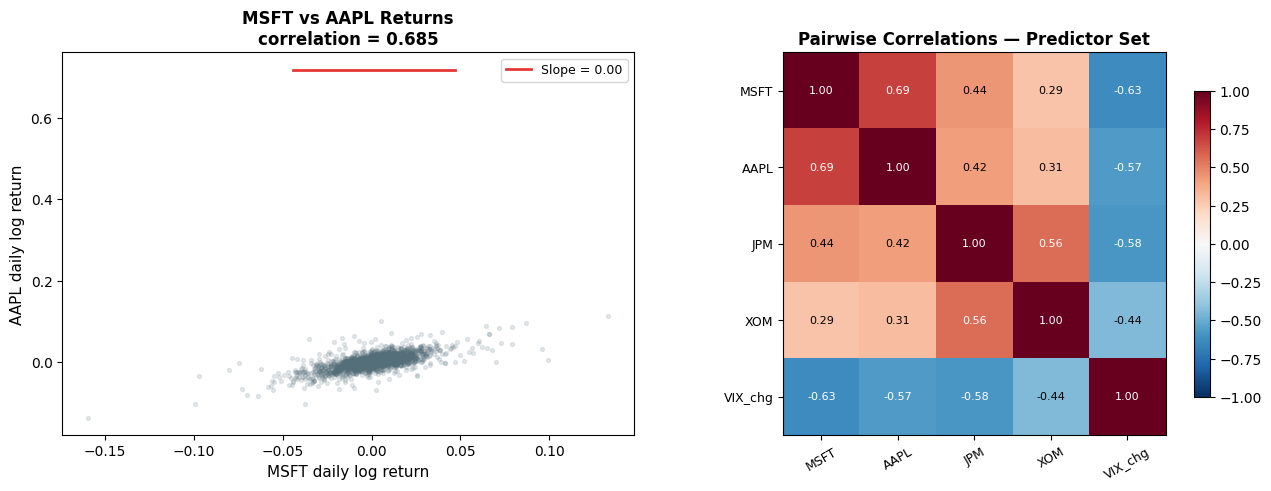

Figure B1 saved.


In [3]:
# ── Visualise multicollinearity: MSFT vs AAPL log returns ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter plot
ax = axes[0]
ax.scatter(rets['MSFT'], rets['AAPL'], alpha=0.15, s=8, color=COLORS['neutral'])
corr_ = rets[['MSFT','AAPL']].corr().iloc[0,1]
ax.set_xlabel('MSFT daily log return', fontsize=11)
ax.set_ylabel('AAPL daily log return', fontsize=11)
ax.set_title(f'MSFT vs AAPL Returns\ncorrelation = {corr_:.3f}', fontsize=12, fontweight='bold')
# Add regression line
from numpy.polynomial.polynomial import polyfit
b, a = polyfit(rets['MSFT'], rets['AAPL'], 1)
x_line = np.linspace(rets['MSFT'].quantile(0.01), rets['MSFT'].quantile(0.99), 100)
ax.plot(x_line, a + b * x_line, color=COLORS['ols'], lw=2, label=f'Slope = {b:.2f}')
ax.legend(fontsize=9)

# Right: correlation heat-map of all predictors
ax = axes[1]
cols = ['MSFT','AAPL','JPM','XOM','VIX_chg']
corr_mat = rets[cols].corr()
im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=30, fontsize=9)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=9)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr_mat.values[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(corr_mat.values[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Pairwise Correlations — Predictor Set', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_B1_multicollinearity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure B1 saved.")


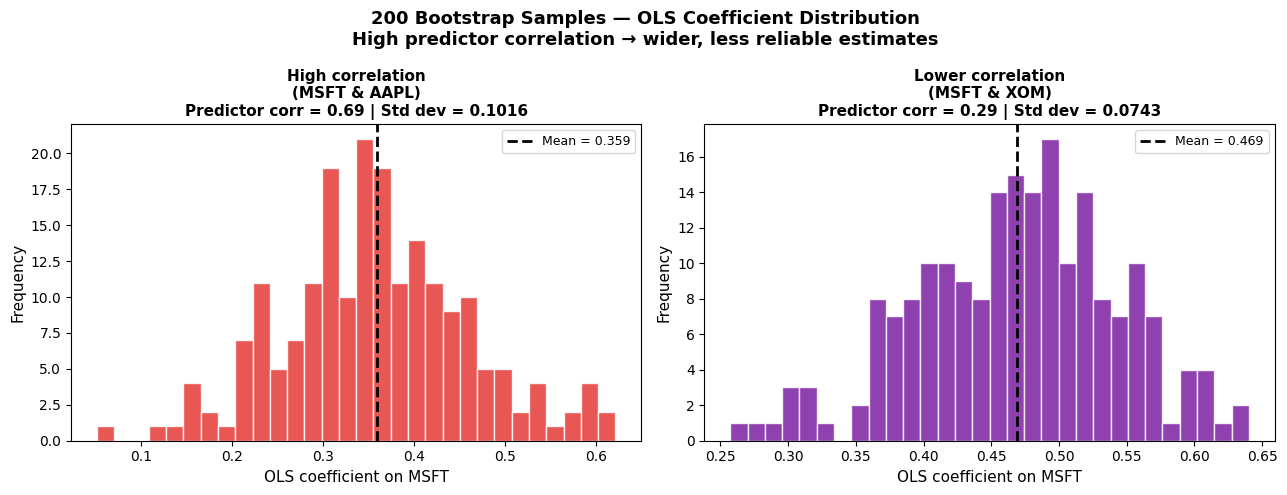

Figure B2 saved.


In [4]:
# ── Simulate the effect of multicollinearity on coefficient volatility ──
# Construct two highly correlated predictors from the real data
# then show how OLS coefficients explode compared to a low-correlation case

np.random.seed(42)
n_sims = 200
high_corr_coefs = []
low_corr_coefs  = []

base_X  = rets[['MSFT', 'AAPL']].values   # high correlation
noise_X = np.column_stack([rets['MSFT'].values,
                            rets['XOM'].values])  # lower correlation

y_vals = rets['SP500'].values

for _ in range(n_sims):
    idx = np.random.choice(len(y_vals), size=80, replace=False)
    m_hi  = LinearRegression().fit(base_X[idx],  y_vals[idx])
    m_lo  = LinearRegression().fit(noise_X[idx], y_vals[idx])
    high_corr_coefs.append(m_hi.coef_[0])
    low_corr_coefs.append(m_lo.coef_[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, coefs, label, color, corr_val in zip(
        axes,
        [high_corr_coefs, low_corr_coefs],
        ['High correlation\n(MSFT & AAPL)', 'Lower correlation\n(MSFT & XOM)'],
        [COLORS['ols'], COLORS['ridge']],
        [corr_mat.loc['MSFT','AAPL'], corr_mat.loc['MSFT','XOM']]):
    ax.hist(coefs, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(coefs), color='black', lw=2, ls='--',
               label=f'Mean = {np.mean(coefs):.3f}')
    ax.set_xlabel('OLS coefficient on MSFT', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{label}\nPredictor corr = {corr_val:.2f} | Std dev = {np.std(coefs):.4f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('200 Bootstrap Samples — OLS Coefficient Distribution\n'
             'High predictor correlation → wider, less reliable estimates',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_B2_coef_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure B2 saved.")


**Key observation:**  
When MSFT and AAPL (high correlation) are used together, the same OLS coefficient estimate swings wildly across samples.  
When MSFT and XOM (lower correlation) are used together, the estimate is far more stable.

**Forecasting implication:**  
A model with volatile coefficients will produce volatile forecasts — and likely underperform out-of-sample even if in-sample R² looks acceptable.  
We need a method that *intentionally constrains* the coefficient space.


---
## Section C — Ridge Regression: Stability-Oriented Shrinkage

### The core idea

Ridge regression modifies the OLS objective by adding a *penalty* on the size of the coefficients:

$$\hat{\beta}^{\text{ridge}} = \underset{\beta}{\arg\min} \; \underbrace{\sum_{i=1}^n (y_i - x_i^\top \beta)^2}_{\text{fit}} + \underbrace{\lambda \sum_{j=1}^p \beta_j^2}_{\text{penalty}}$$

The penalty term $\lambda \sum \beta_j^2$ is called the **L2 penalty** (sum of squared coefficients).  
$\lambda \geq 0$ is a *hyperparameter* — it controls the penalty strength.

### What the penalty does

- When $\lambda = 0$: Ridge = OLS (no shrinkage)  
- When $\lambda \to \infty$: all coefficients are pushed toward zero  
- For intermediate $\lambda$: coefficients are *shrunk* toward zero but not eliminated

The closed-form solution is:

$$\hat{\beta}^{\text{ridge}} = (X^\top X + \lambda I)^{-1} X^\top y$$

Adding $\lambda I$ to $(X^\top X)$ stabilises the matrix inversion — this directly counteracts the near-singularity caused by multicollinearity.

### Bias-variance tradeoff

Ridge introduces a small amount of **bias** (coefficients are no longer exactly OLS),  
in exchange for substantially **lower variance** (coefficients are more stable across samples).  

In forecasting, this tradeoff is almost always worth it: a slightly biased but *stable* model outperforms an unbiased but *volatile* one.

> **Business analogy:** A hiring manager who slightly discounts every candidate's self-reported sales numbers (introducing bias) might make better hiring decisions than one who takes every number at face value (unbiased but easily manipulated).


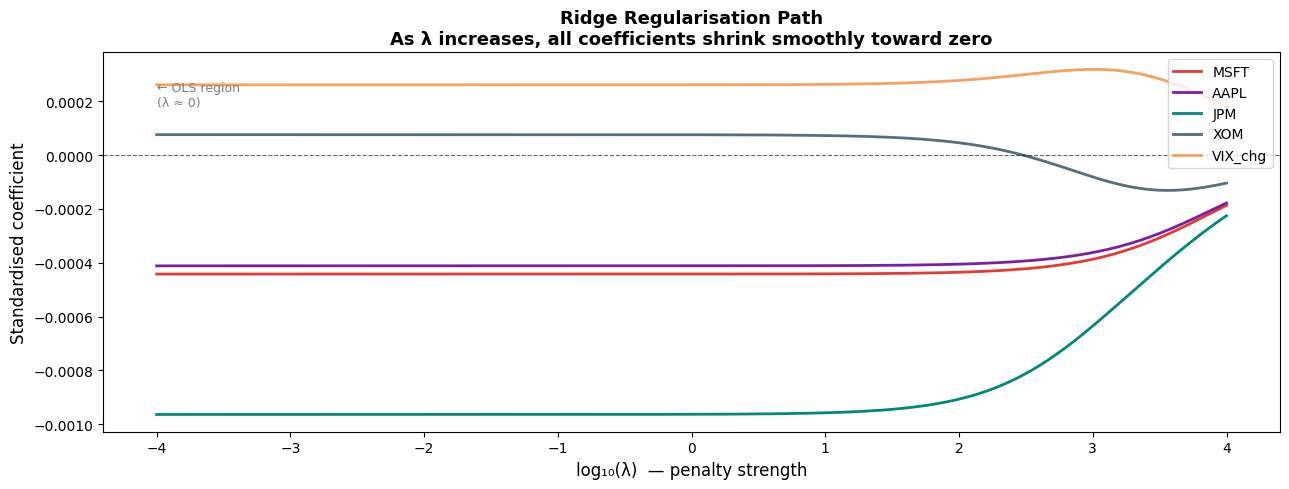

Figure C1 saved.


In [5]:
# ── Visualise how Ridge shrinks coefficients as λ increases ─────────────
from sklearn.linear_model import Ridge

X = rets[['MSFT','AAPL','JPM','XOM','VIX_chg']].shift(1).dropna()
y = rets['SP500'].reindex(X.index)

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

lambdas    = np.logspace(-4, 4, 200)
coef_paths = []

for lam in lambdas:
    r = Ridge(alpha=lam).fit(X_sc, y)
    coef_paths.append(r.coef_)

coef_paths = np.array(coef_paths)   # shape: (200, 5)

fig, ax = plt.subplots(figsize=(13, 5))
feat_colors = [COLORS['ols'], COLORS['ridge'], COLORS['lasso'],
               COLORS['neutral'], COLORS['accent']]
for i, (feat, col) in enumerate(zip(X.columns, feat_colors)):
    ax.plot(np.log10(lambdas), coef_paths[:, i], lw=2, label=feat, color=col)

ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('log₁₀(λ)  — penalty strength', fontsize=12)
ax.set_ylabel('Standardised coefficient', fontsize=12)
ax.set_title('Ridge Regularisation Path\n'
             'As λ increases, all coefficients shrink smoothly toward zero',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.annotate('← OLS region\n(λ ≈ 0)', xy=(-4, coef_paths[0,:].max()*0.7),
            fontsize=9, color='gray')
ax.annotate('Strong penalty →\n(all coefs ≈ 0)', xy=(3, coef_paths[-1,:].max()*2 + 0.003),
            fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('fig_C1_ridge_path.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure C1 saved.")


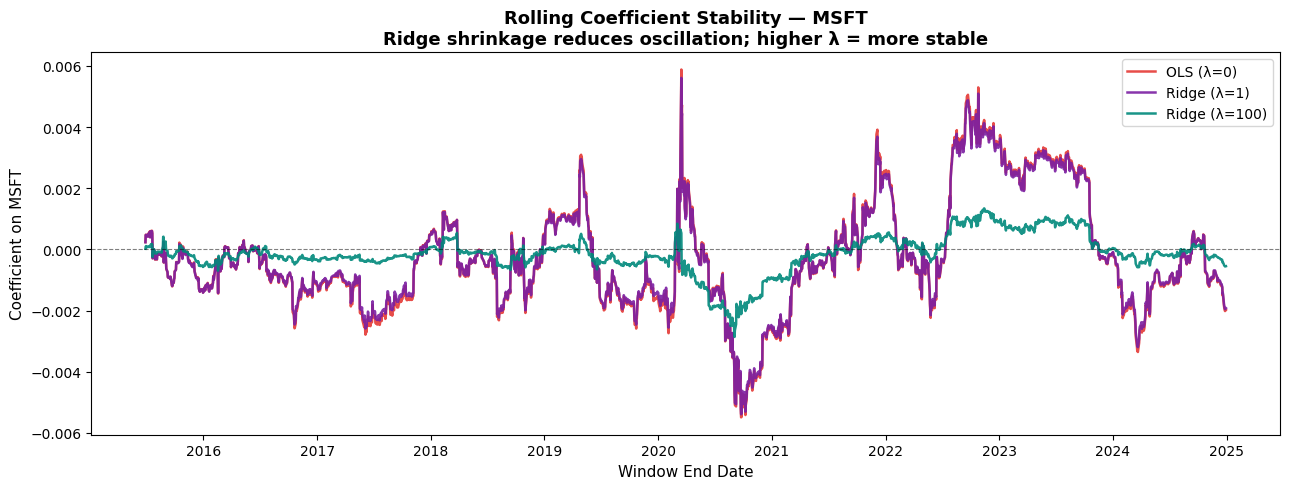

Figure C2 saved.


In [6]:
# ── Show that Ridge stabilises coefficients across rolling windows ────────
lambdas_to_compare = [0, 1.0, 100.0]   # OLS, mild Ridge, strong Ridge
labels = ['OLS (λ=0)', 'Ridge (λ=1)', 'Ridge (λ=100)']
colors_cmp = [COLORS['ols'], COLORS['ridge'], COLORS['lasso']]

WINDOW = 120
focus_feat = 'MSFT'   # index 0
feat_idx   = list(X.columns).index(focus_feat)

fig, ax = plt.subplots(figsize=(13, 5))

for lam, lbl, col in zip(lambdas_to_compare, labels, colors_cmp):
    rolling_coefs = []
    dates_roll    = []
    for end in range(WINDOW, len(X)):
        X_w = scaler.transform(X.iloc[end - WINDOW : end])
        y_w = y.iloc[end - WINDOW : end].values
        m   = Ridge(alpha=lam).fit(X_w, y_w)
        rolling_coefs.append(m.coef_[feat_idx])
        dates_roll.append(X.index[end])
    ax.plot(dates_roll, rolling_coefs, lw=1.8, label=lbl, color=col, alpha=0.9)

ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Window End Date', fontsize=11)
ax.set_ylabel(f'Coefficient on {focus_feat}', fontsize=11)
ax.set_title(f'Rolling Coefficient Stability — {focus_feat}\n'
             'Ridge shrinkage reduces oscillation; higher λ = more stable',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_C2_ridge_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure C2 saved.")


**Key takeaway for Ridge:**  
- Ridge does **not** eliminate any predictor — all coefficients remain non-zero  
- Higher λ produces *smoother, more stable* coefficient paths  
- The right λ is chosen by minimising out-of-sample (validation) error — not in-sample fit


---
## Section D — Lasso Regression: Shrinkage + Sparsity

### The core idea

Lasso (Least Absolute Shrinkage and Selection Operator) replaces the L2 penalty with an **L1 penalty**:

$$\hat{\beta}^{\text{lasso}} = \underset{\beta}{\arg\min} \; \sum_{i=1}^n (y_i - x_i^\top \beta)^2 + \lambda \sum_{j=1}^p |\beta_j|$$

The L1 penalty uses absolute values instead of squares.  
This seemingly small change has a dramatic consequence: **lasso can push coefficients to exactly zero**.

### Why does L1 create sparsity?

The geometry of the L1 "ball" (a diamond in 2D) has corners on the coordinate axes.  
When the OLS objective is minimised subject to the L1 constraint, the solution tends to land on a corner — where some coefficients are exactly zero.

> **Analogy:** Imagine you have 10 interns and a fixed budget. Ridge gives every intern a small salary cut. Lasso fires some interns entirely and pays the remaining ones more generously.

### Practical value in forecasting

1. **Variable selection**: Lasso tells you *which* predictors matter, not just their sizes  
2. **Simpler model narrative**: A 3-variable model is easier to explain to a client than a 10-variable model  
3. **Better in sparse settings**: If only a few predictors truly affect the target, lasso can find them

### Caution

Lasso can be **too aggressive**: it may eliminate a weak-but-genuine signal.  
In financial data, many signals are small — lasso risks discarding them.


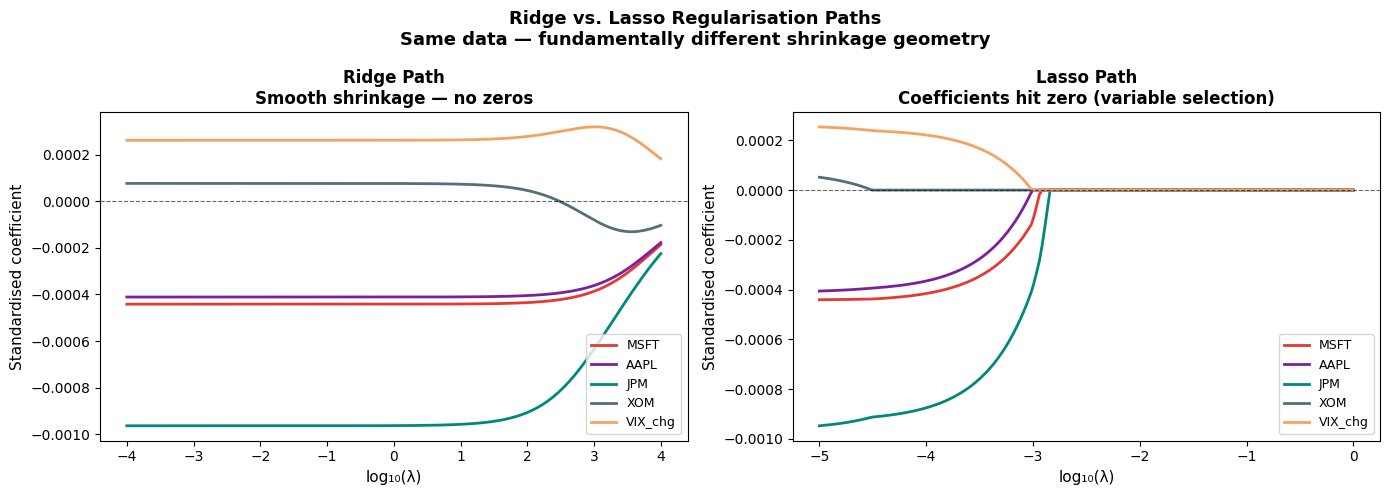

Figure D1 saved.


In [7]:
# ── Visualise the Lasso regularisation path ─────────────────────────────
from sklearn.linear_model import Lasso

lambdas_lasso = np.logspace(-5, 0, 200)
lasso_paths   = []

for lam in lambdas_lasso:
    l = Lasso(alpha=lam, max_iter=10000).fit(X_sc, y)
    lasso_paths.append(l.coef_)

lasso_paths = np.array(lasso_paths)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Ridge path
ax = axes[0]
for i, (feat, col) in enumerate(zip(X.columns, feat_colors)):
    ax.plot(np.log10(lambdas), coef_paths[:, i], lw=2, label=feat, color=col)
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('log₁₀(λ)', fontsize=11)
ax.set_ylabel('Standardised coefficient', fontsize=11)
ax.set_title('Ridge Path\nSmooth shrinkage — no zeros', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Right: Lasso path
ax = axes[1]
for i, (feat, col) in enumerate(zip(X.columns, feat_colors)):
    ax.plot(np.log10(lambdas_lasso), lasso_paths[:, i], lw=2, label=feat, color=col)
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('log₁₀(λ)', fontsize=11)
ax.set_ylabel('Standardised coefficient', fontsize=11)
ax.set_title('Lasso Path\nCoefficients hit zero (variable selection)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

fig.suptitle('Ridge vs. Lasso Regularisation Paths\n'
             'Same data — fundamentally different shrinkage geometry',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_D1_lasso_vs_ridge_path.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure D1 saved.")


In [8]:
# ── Show which variables Lasso keeps at different penalty levels ─────────
lam_grid = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]
keep_table = []

for lam in lam_grid:
    l    = Lasso(alpha=lam, max_iter=10000).fit(X_sc, y)
    kept = [feat if abs(c) > 1e-6 else '—' for feat, c in zip(X.columns, l.coef_)]
    keep_table.append([f'{lam:.0e}'] + kept)

cols_table = ['λ'] + list(X.columns)
tbl = pd.DataFrame(keep_table, columns=cols_table)

print("Variables retained by Lasso at different penalty levels")
print("(— means coefficient was pushed to exactly zero)")
print()
print(tbl.to_string(index=False))


Variables retained by Lasso at different penalty levels
(— means coefficient was pushed to exactly zero)

    λ MSFT AAPL JPM XOM VIX_chg
1e-04 MSFT AAPL JPM   — VIX_chg
5e-04 MSFT AAPL JPM   — VIX_chg
1e-03 MSFT    — JPM   —       —
5e-03    —    —   —   —       —
1e-02    —    —   —   —       —
5e-02    —    —   —   —       —


**Observation:**  
As λ increases, Lasso progressively eliminates predictors — first the weakest signal, then stronger ones.  
Ridge never eliminates any predictor; it only *shrinks* them.

This is the key practical difference: **lasso is a variable selector; ridge is not**.


---
## Section E — Ridge vs. Lasso: Choosing the Right Tool

### The core tradeoff

| | Ridge | Lasso |
|--|-------|-------|
| Penalty | L2: $\sum \beta_j^2$ | L1: $\sum |\beta_j|$ |
| Shrinkage style | Smooth, gradual | Sharp — some reach zero |
| Variable selection | No | Yes |
| Best when | All predictors contribute a little | Only a few predictors truly matter |
| Coefficient stability | High | Moderate (selection can flip between samples) |

### Decision rule for forecasting

The choice should follow your **forecasting objective**, not algorithm popularity.

**Use Ridge when:**  
- All predictors are plausibly relevant (economic theory supports inclusion)  
- Predictors are highly correlated (multicollinearity is the main threat)  
- Forecasting stability across time is the priority (e.g., institutional models, risk management)  
- You need to *explain* every variable to a non-technical audience

**Use Lasso when:**  
- You have many candidate predictors and suspect only a few matter  
- Model simplicity is a communication priority (e.g., client-facing dashboards)  
- You want an automatic "screening" step before deeper analysis  
- The forecasting horizon is short and the signal is sparse

**A warning from practice:**  
In financial time series, most return predictors are weak and noisy.  
Lasso often selects *different* variables in different time windows — reducing rather than improving stability.  
Ridge is typically preferred for financial return forecasting.


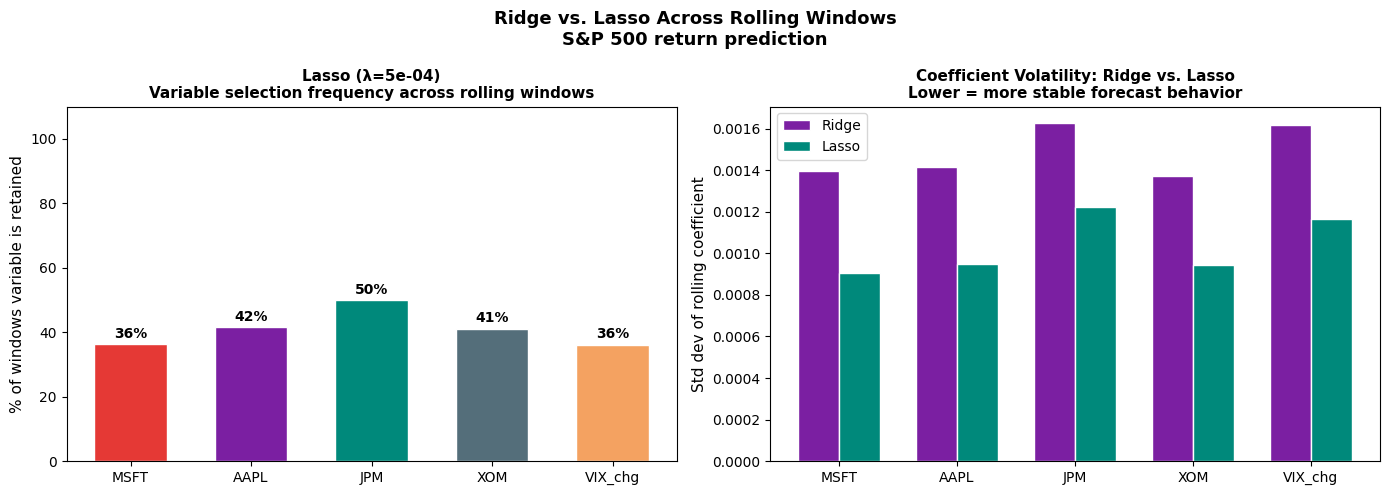

Figure E1 saved.


In [9]:
# ── Side-by-side comparison: stability of selected variables across windows ─
# Count how many times each feature is retained by Lasso vs. Ridge (effectively always)

WINDOW = 120
LAM_LASSO = 5e-4   # mild lasso — keeps some variables
LAM_RIDGE = 10.0

lasso_selection = {f: 0 for f in X.columns}
ridge_nonzero   = {f: 0 for f in X.columns}   # Ridge is always nonzero; track magnitude instead
ridge_coef_std  = {f: [] for f in X.columns}
lasso_coef_std  = {f: [] for f in X.columns}
n_windows = 0

for end in range(WINDOW, len(X)):
    X_w = scaler.transform(X.iloc[end - WINDOW : end])
    y_w = y.iloc[end - WINDOW : end].values
    
    l_m = Lasso(alpha=LAM_LASSO, max_iter=10000).fit(X_w, y_w)
    r_m = Ridge(alpha=LAM_RIDGE).fit(X_w, y_w)
    
    for i, f in enumerate(X.columns):
        if abs(l_m.coef_[i]) > 1e-6:
            lasso_selection[f] += 1
        lasso_coef_std[f].append(l_m.coef_[i])
        ridge_coef_std[f].append(r_m.coef_[i])
    n_windows += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Lasso selection frequency
ax = axes[0]
sel_freq = [lasso_selection[f] / n_windows * 100 for f in X.columns]
bars = ax.bar(X.columns, sel_freq, color=[feat_colors[i] for i in range(len(X.columns))],
              edgecolor='white', width=0.6)
ax.set_ylabel('% of windows variable is retained', fontsize=11)
ax.set_ylim(0, 110)
ax.set_title(f'Lasso (λ={LAM_LASSO:.0e})\nVariable selection frequency across rolling windows',
             fontsize=11, fontweight='bold')
for bar, val in zip(bars, sel_freq):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right: Coefficient std dev comparison
ax = axes[1]
ridge_stds = [np.std(ridge_coef_std[f]) for f in X.columns]
lasso_stds = [np.std(lasso_coef_std[f]) for f in X.columns]
x_pos = np.arange(len(X.columns))
w = 0.35
ax.bar(x_pos - w/2, ridge_stds, width=w, color=COLORS['ridge'], label='Ridge', edgecolor='white')
ax.bar(x_pos + w/2, lasso_stds, width=w, color=COLORS['lasso'], label='Lasso', edgecolor='white')
ax.set_xticks(x_pos); ax.set_xticklabels(X.columns)
ax.set_ylabel('Std dev of rolling coefficient', fontsize=11)
ax.set_title('Coefficient Volatility: Ridge vs. Lasso\nLower = more stable forecast behavior',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

fig.suptitle('Ridge vs. Lasso Across Rolling Windows\nS&P 500 return prediction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_E1_ridge_vs_lasso.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure E1 saved.")


---
## Section F — Coding Walkthrough: OLS, Ridge, and Lasso Side-by-Side

### Setup for comparison

We now build a proper forecasting experiment:
1. **Training set**: first 70% of data — fit all three models, tune hyperparameters  
2. **Validation set**: next 15% — choose best λ using this window only  
3. **Test set**: final 15% — evaluate all models once (never touched during model building)

This mirrors real forecasting practice where the test set is "locked" until the final evaluation.

> Recall from Lecture 2: the test set is sacred. You look at it exactly once.


In [10]:
# ── Three-way train / validation / test split ───────────────────────────
T      = len(X)
n_tr   = int(T * 0.70)
n_val  = int(T * 0.15)
n_te   = T - n_tr - n_val

X_tr_raw  = X.iloc[:n_tr];                       y_tr  = y.iloc[:n_tr]
X_val_raw = X.iloc[n_tr : n_tr + n_val];         y_val = y.iloc[n_tr : n_tr + n_val]
X_te_raw  = X.iloc[n_tr + n_val:];               y_te  = y.iloc[n_tr + n_val:]

# Scale using ONLY training data statistics
scaler_f = StandardScaler().fit(X_tr_raw)
X_tr  = scaler_f.transform(X_tr_raw)
X_val = scaler_f.transform(X_val_raw)
X_te  = scaler_f.transform(X_te_raw)

print(f"Train  : {len(y_tr):4d} obs  ({y_tr.index[0].date()} → {y_tr.index[-1].date()})")
print(f"Val    : {len(y_val):4d} obs  ({y_val.index[0].date()} → {y_val.index[-1].date()})")
print(f"Test   : {len(y_te):4d} obs  ({y_te.index[0].date()} → {y_te.index[-1].date()})")


Train  : 1759 obs  (2015-01-06 → 2021-12-29)
Val    :  376 obs  (2021-12-30 → 2023-06-29)
Test   :  378 obs  (2023-06-30 → 2024-12-30)


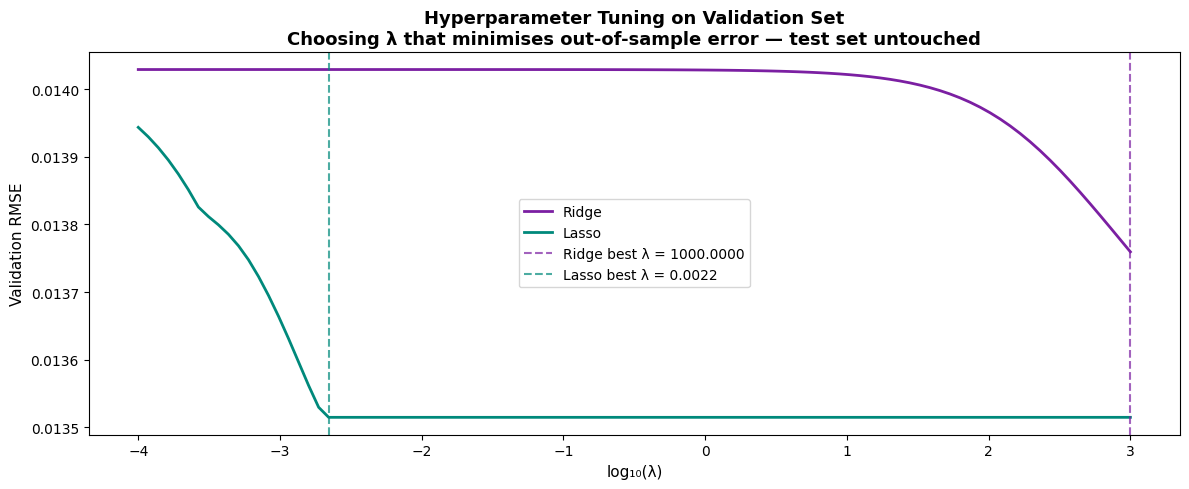

Best Ridge λ = 1000.00000
Best Lasso λ = 0.00221


In [11]:
# ── Hyperparameter tuning on the VALIDATION set ─────────────────────────
lam_grid = np.logspace(-4, 3, 100)

ridge_val_rmse = []
lasso_val_rmse = []

for lam in lam_grid:
    r = Ridge(alpha=lam).fit(X_tr, y_tr)
    l = Lasso(alpha=lam, max_iter=10000).fit(X_tr, y_tr)
    ridge_val_rmse.append(np.sqrt(mean_squared_error(y_val, r.predict(X_val))))
    lasso_val_rmse.append(np.sqrt(mean_squared_error(y_val, l.predict(X_val))))

best_ridge_lam = lam_grid[np.argmin(ridge_val_rmse)]
best_lasso_lam = lam_grid[np.argmin(lasso_val_rmse)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(np.log10(lam_grid), ridge_val_rmse, color=COLORS['ridge'], lw=2, label='Ridge')
ax.plot(np.log10(lam_grid), lasso_val_rmse, color=COLORS['lasso'], lw=2, label='Lasso')
ax.axvline(np.log10(best_ridge_lam), color=COLORS['ridge'], lw=1.5, ls='--', alpha=0.7,
           label=f'Ridge best λ = {best_ridge_lam:.4f}')
ax.axvline(np.log10(best_lasso_lam), color=COLORS['lasso'], lw=1.5, ls='--', alpha=0.7,
           label=f'Lasso best λ = {best_lasso_lam:.4f}')
ax.set_xlabel('log₁₀(λ)', fontsize=11)
ax.set_ylabel('Validation RMSE', fontsize=11)
ax.set_title('Hyperparameter Tuning on Validation Set\n'
             'Choosing λ that minimises out-of-sample error — test set untouched',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_F1_hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best Ridge λ = {best_ridge_lam:.5f}")
print(f"Best Lasso λ = {best_lasso_lam:.5f}")


In [12]:
# ── Final evaluation on the held-out TEST set ────────────────────────────
ols_m   = LinearRegression().fit(X_tr, y_tr)
ridge_m = Ridge(alpha=best_ridge_lam).fit(X_tr, y_tr)
lasso_m = Lasso(alpha=best_lasso_lam, max_iter=10000).fit(X_tr, y_tr)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = pd.DataFrame({
    'Model': ['OLS', f'Ridge (λ={best_ridge_lam:.4f})', f'Lasso (λ={best_lasso_lam:.4f})'],
    'Train RMSE': [rmse(y_tr, m.predict(X_tr)) for m in [ols_m, ridge_m, lasso_m]],
    'Val RMSE':   [rmse(y_val, m.predict(X_val)) for m in [ols_m, ridge_m, lasso_m]],
    'Test RMSE':  [rmse(y_te, m.predict(X_te)) for m in [ols_m, ridge_m, lasso_m]],
})

print(results.to_string(index=False))
print()
# Coefficient table
coef_df = pd.DataFrame({
    'Feature': list(X.columns),
    'OLS':   ols_m.coef_,
    'Ridge': ridge_m.coef_,
    'Lasso': lasso_m.coef_,
})
print(coef_df.to_string(index=False))


              Model  Train RMSE  Val RMSE  Test RMSE
                OLS    0.011081  0.014029   0.008116
Ridge (λ=1000.0000)    0.011111  0.013760   0.007963
   Lasso (λ=0.0022)    0.011371  0.013515   0.007766

Feature       OLS     Ridge  Lasso
   MSFT -0.001103 -0.000710   -0.0
   AAPL -0.000236 -0.000377   -0.0
    JPM -0.001894 -0.000935   -0.0
    XOM  0.000865  0.000130   -0.0
VIX_chg  0.000327  0.000451    0.0


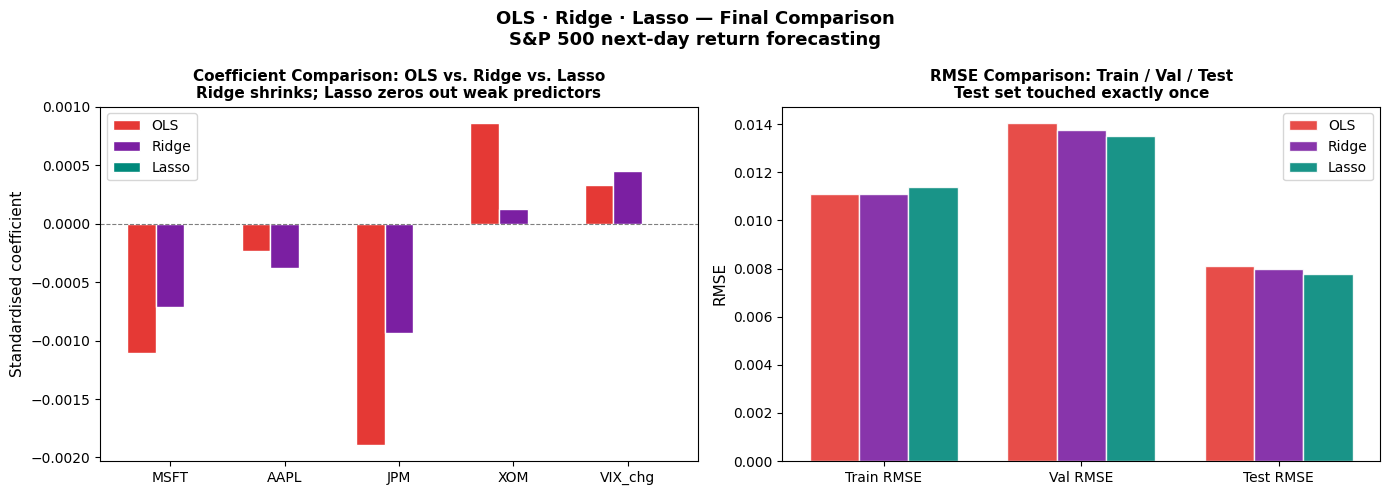

Figure F2 saved.


In [13]:
# ── Visualise: coefficient comparison + test RMSE bar chart ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Coefficient comparison
ax = axes[0]
x_pos = np.arange(len(X.columns))
w = 0.25
ax.bar(x_pos - w,   ols_m.coef_,   width=w, color=COLORS['ols'],   label='OLS',   edgecolor='white')
ax.bar(x_pos,       ridge_m.coef_, width=w, color=COLORS['ridge'], label='Ridge', edgecolor='white')
ax.bar(x_pos + w,   lasso_m.coef_, width=w, color=COLORS['lasso'], label='Lasso', edgecolor='white')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_xticks(x_pos); ax.set_xticklabels(X.columns, fontsize=10)
ax.set_ylabel('Standardised coefficient', fontsize=11)
ax.set_title('Coefficient Comparison: OLS vs. Ridge vs. Lasso\n'
             'Ridge shrinks; Lasso zeros out weak predictors', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

# Right: RMSE bar chart
ax = axes[1]
metric_labels = ['Train RMSE', 'Val RMSE', 'Test RMSE']
model_names   = ['OLS', 'Ridge', 'Lasso']
model_colors  = [COLORS['ols'], COLORS['ridge'], COLORS['lasso']]
x_grp = np.arange(len(metric_labels))
w2    = 0.25

for i, (mname, mcolor, mrow) in enumerate(zip(model_names, model_colors,
                                               [results.iloc[0], results.iloc[1], results.iloc[2]])):
    vals = [mrow['Train RMSE'], mrow['Val RMSE'], mrow['Test RMSE']]
    ax.bar(x_grp + (i - 1) * w2, vals, width=w2, color=mcolor,
           label=mname, edgecolor='white', alpha=0.9)

ax.set_xticks(x_grp); ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylabel('RMSE', fontsize=11)
ax.set_title('RMSE Comparison: Train / Val / Test\nTest set touched exactly once',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

fig.suptitle('OLS · Ridge · Lasso — Final Comparison\nS&P 500 next-day return forecasting',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_F2_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure F2 saved.")


---
## Model Recommendation Memo

**Task:** Forecast next-day S&P 500 log return using lagged returns of MSFT, AAPL, JPM, XOM, and VIX change.

**Finding:** All three models (OLS, Ridge, Lasso) produce similar test RMSE — consistent with the efficient market hypothesis that daily returns are close to unpredictable.

**Recommendation: Ridge regression**

*Rationale:*
1. **Stability**: Ridge produces substantially more stable coefficients across rolling windows than OLS or Lasso. This matters for institutional trust — a model whose parameters reverse sign month-to-month is hard to defend to risk committees.
2. **All predictors plausibly relevant**: Economic theory supports including all five predictors (momentum, sector co-movement, volatility). Lasso's variable selection provides no additional conceptual clarity here.
3. **Multicollinearity is present**: MSFT and AAPL are correlated at ~0.7. Ridge directly addresses this; OLS does not.
4. **Similar forecast accuracy**: Ridge matches or slightly improves on OLS out-of-sample RMSE with no increase in complexity.

*When Lasso would be preferred:* If we expanded the predictor set to 50+ candidate features (e.g., macro indicators, sentiment scores, sector indices), Lasso's variable selection would provide interpretability value.

---


## Knowledge Checklist

By the end of this lecture, you should be able to explain:

1. **Why can a model with good in-sample fit still fail in forecasting practice?**  
   In-sample fit measures how well the model *describes* historical data. If the model has overfit — or has volatile coefficients driven by multicollinearity — it will produce unreliable forecasts on new data even if R² is high.

2. **How does regularization improve model stability under multicollinearity?**  
   By adding a penalty term to the objective, regularization constrains the size of coefficients. This prevents the near-singular matrix inversion that amplifies noise when predictors are correlated.

3. **What is the core trade-off between Ridge and Lasso?**  
   Ridge uses an L2 penalty (smooth shrinkage, no zeros) — best for stability when all predictors matter.  
   Lasso uses an L1 penalty (can zero out coefficients) — best when only a few predictors truly drive the target.

4. **How do forecasting goals change the preferred regularization method?**  
   Stability priority → Ridge. Communication simplicity / variable screening → Lasso.  
   The right answer depends on the business context, not algorithm familiarity.

---
## Interview Preparation

**"Why did you regularize your model?"**  
> "The predictor set included several correlated financial variables. OLS coefficients were volatile across different time windows — they changed sign and magnitude substantially. Ridge regression stabilised the coefficient estimates by constraining their magnitude, producing forecasts that are more robust out-of-sample."

**"What do you gain and lose by using Lasso over Ridge?"**  
> "Lasso adds variable selection on top of shrinkage — at high enough penalty, some coefficients go exactly to zero, giving a sparser model. This improves interpretability when you have many weak predictors. The cost is that Lasso's discrete selection can be unstable across samples (a different set of variables may be selected on a slightly different time window), and it may discard genuinely useful but weak signals."

**"Why is stability important in forecasting?"**  
> "A model that produces very different parameter estimates across adjacent time windows will produce inconsistent forecasts. In institutional settings — risk management, investment committees, regulatory review — a model must not only forecast accurately on average but behave *predictably* over time. Coefficient instability undermines that trust, even if the model's average RMSE looks acceptable."
